#📌 Extracción

In [6]:
import pandas as pd

# URL en formato raw para que pandas pueda leer el contenido directamente
url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"

# Intentamos cargar los datos
try:
    df = pd.read_json(url)
    print("¡Datos cargados exitosamente!")
except Exception as e:
    print(f"Hubo un error al cargar los datos: {e}")

# Visualizar las primeras filas
df.head()

¡Datos cargados exitosamente!


,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


In [21]:
import requests
import json
import pandas as pd

# Obtener los datos con requests
response = requests.get(url)
data = response.json()

# Normalizar el JSON (esto expande los diccionarios en columnas separadas)
df = pd.json_normalize(data)

# Revisar la estructura resultante
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupport       7267 non-null   objec

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


#🔧 Transformación

In [22]:
# Reemplazamos los puntos por guiones bajos
df.columns = [col.replace('.', '_') for col in df.columns]

# Convertir a numérico, transformando errores (espacios vacíos) en NaN
df['account_Charges_Total'] = pd.to_numeric(df['account_Charges_Total'], errors='coerce')

# Verificar cuántos nulos se generaron (suelen ser clientes con tenure = 0)
print(f"Valores nulos en Total Charges: {df['account_Charges_Total'].isnull().sum()}")

# Llenar esos nulos con 0 (ya que si no tienen meses de antigüedad, su cargo total es 0)
df['account_Charges_Total'] = df['account_Charges_Total'].fillna(0)

# Verificamos valores únicos
print("Valores en Churn antes de limpiar:", df['Churn'].unique())

# Filtramos solo registros que tengan 'Yes' o 'No' (eliminamos vacíos)
df = df[df['Churn'] != '']
df = df[df['Churn'].notnull()]

# Opcional: Mapear a binario (0 y 1) para el equipo de ML
# df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Seleccionamos las columnas tipo objeto
columns_obj = df.select_dtypes(include=['object']).columns

# Aplicamos strip() para eliminar espacios en blanco residuales
for col in columns_obj:
    df[col] = df[col].str.strip()

df.info()

Valores nulos en Total Charges: 11
Valores en Churn antes de limpiar: ['No' 'Yes' '']
<class 'pandas.core.frame.DataFrame'>
Index: 7043 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7043 non-null   object 
 1   Churn                      7043 non-null   object 
 2   customer_gender            7043 non-null   object 
 3   customer_SeniorCitizen     7043 non-null   int64  
 4   customer_Partner           7043 non-null   object 
 5   customer_Dependents        7043 non-null   object 
 6   customer_tenure            7043 non-null   int64  
 7   phone_PhoneService         7043 non-null   object 
 8   phone_MultipleLines        7043 non-null   object 
 9   internet_InternetService   7043 non-null   object 
 10  internet_OnlineSecurity    7043 non-null   object 
 11  internet_OnlineBackup      7043 non-null   object 
 12  internet_DeviceProtecti

In [25]:
# Verificar duplicados por customerID
duplicados = df.duplicated(subset=['customerID']).sum()
print(f"Registros duplicados: {duplicados}")

# En caso de haberlos, los eliminamos:
if duplicados > 0:
    df = df.drop_duplicates(subset=['customerID'])

# Revisar consistencia en categorías clave
for col in ['customer_gender', 'customer_Partner', 'customer_Dependents', 'account_Contract']:
    print(f"Valores únicos en {col}: {df[col].unique()}")

Registros duplicados: 0
Valores únicos en customer_gender: ['Female' 'Male']
Valores únicos en customer_Partner: ['Yes' 'No']
Valores únicos en customer_Dependents: ['Yes' 'No']
Valores únicos en account_Contract: ['One year' 'Month-to-month' 'Two year']


In [27]:
# Suponiendo un mes estándar de 30 días para la facturación
df['account_Charges_Daily'] = (df['account_Charges_Monthly'] / 30).round(2)

# Verificamos la creación
df[['account_Charges_Monthly', 'account_Charges_Daily']].head()

,account_Charges_Monthly,account_Charges_Daily
0,65.6,2.19
1,59.9,2.00
2,73.9,2.46
3,98.0,3.27
4,83.9,2.80


#📊 Carga y análisis

In [37]:
# Estadísticas descriptivas para variables numéricas
descriptive_stats = df.describe()
print(descriptive_stats)

# Opcional: descripción de variables categóricas
#print(df.describe(include=['object']))

       customer_SeniorCitizen  customer_tenure  account_Charges_Monthly  \
count             7043.000000      7043.000000              7043.000000   
mean                 0.162147        32.371149                64.761692   
std                  0.368612        24.559481                30.090047   
min                  0.000000         0.000000                18.250000   
25%                  0.000000         9.000000                35.500000   
50%                  0.000000        29.000000                70.350000   
75%                  0.000000        55.000000                89.850000   
max                  1.000000        72.000000               118.750000   

       account_Charges_Total  account_Charges_Daily  
count            7043.000000            7043.000000  
mean             2279.734304               2.158675  
std              2266.794470               1.003088  
min                 0.000000               0.610000  
25%               398.550000               1.180000  


/tmp/ipykernel_291/1922062396.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Churn', data=df, palette='magma')


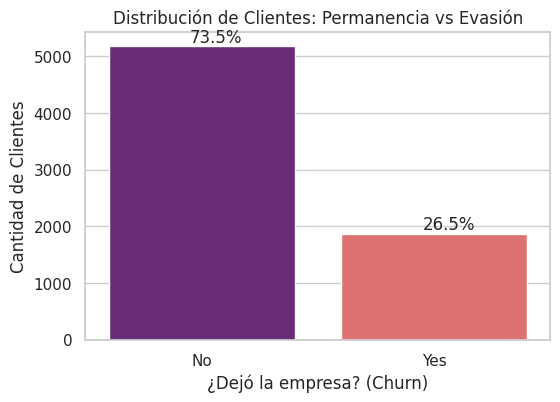

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))
ax = sns.countplot(x='Churn', data=df, palette='magma')
plt.title('Distribución de Clientes: Permanencia vs Evasión')
plt.xlabel('¿Dejó la empresa? (Churn)')
plt.ylabel('Cantidad de Clientes')

# Añadir etiquetas de porcentaje sobre las barras
total = len(df)
for p in ax.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height()/total)
    x = p.get_x() + p.get_width() / 2 - 0.05
    y = p.get_height()
    ax.annotate(percentage, (x, y), size = 12, va='bottom')

plt.show()

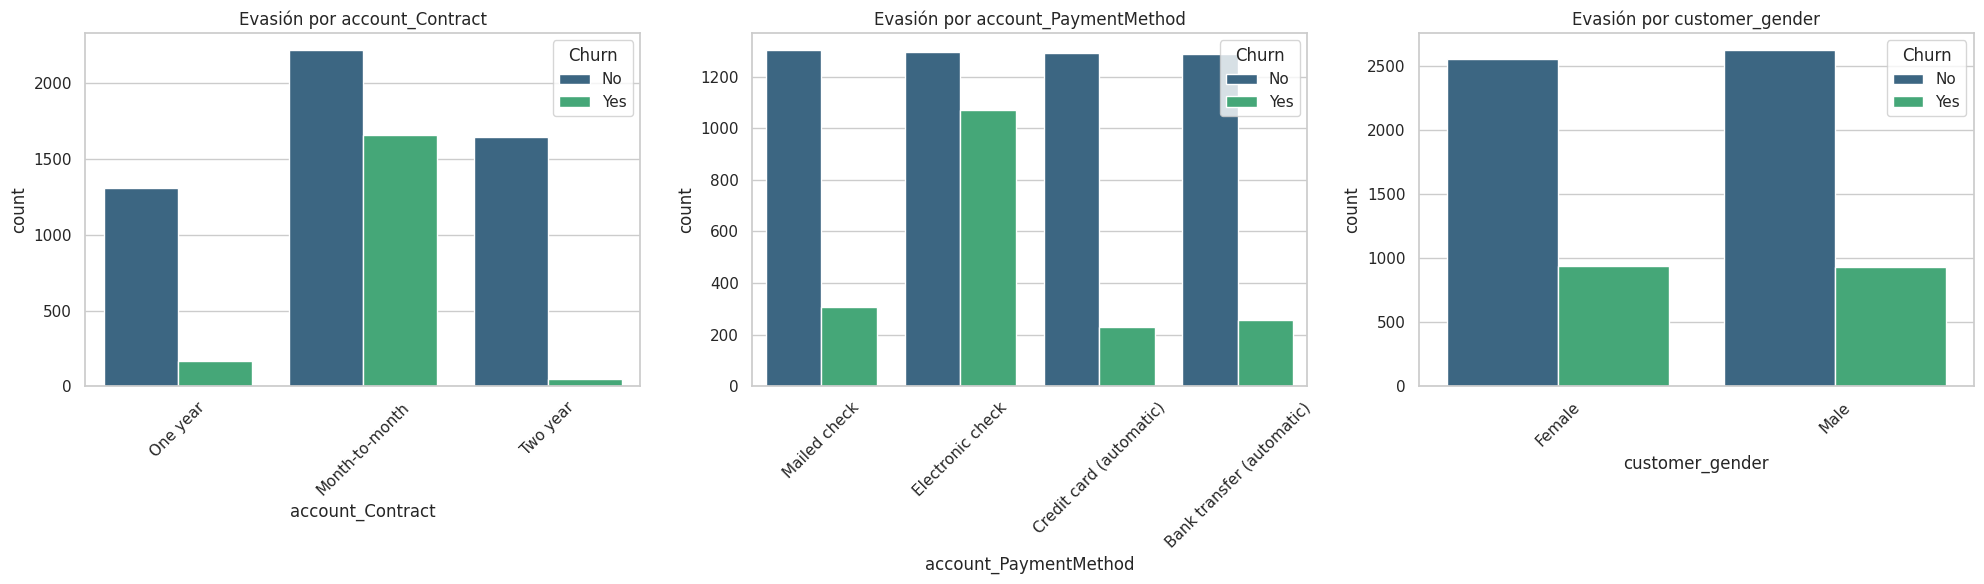

In [31]:
categorical_features = ['account_Contract', 'account_PaymentMethod', 'customer_gender']

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(20, 6))

for i, feature in enumerate(categorical_features):
    sns.countplot(x=feature, hue='Churn', data=df, ax=axes[i], palette='viridis')
    axes[i].set_title(f'Evasión por {feature}')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

/tmp/ipykernel_291/1430911082.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='customer_tenure', data=df, ax=axes[0], palette='coolwarm')
/tmp/ipykernel_291/1430911082.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='account_Charges_Monthly', data=df, ax=axes[1], palette='coolwarm')


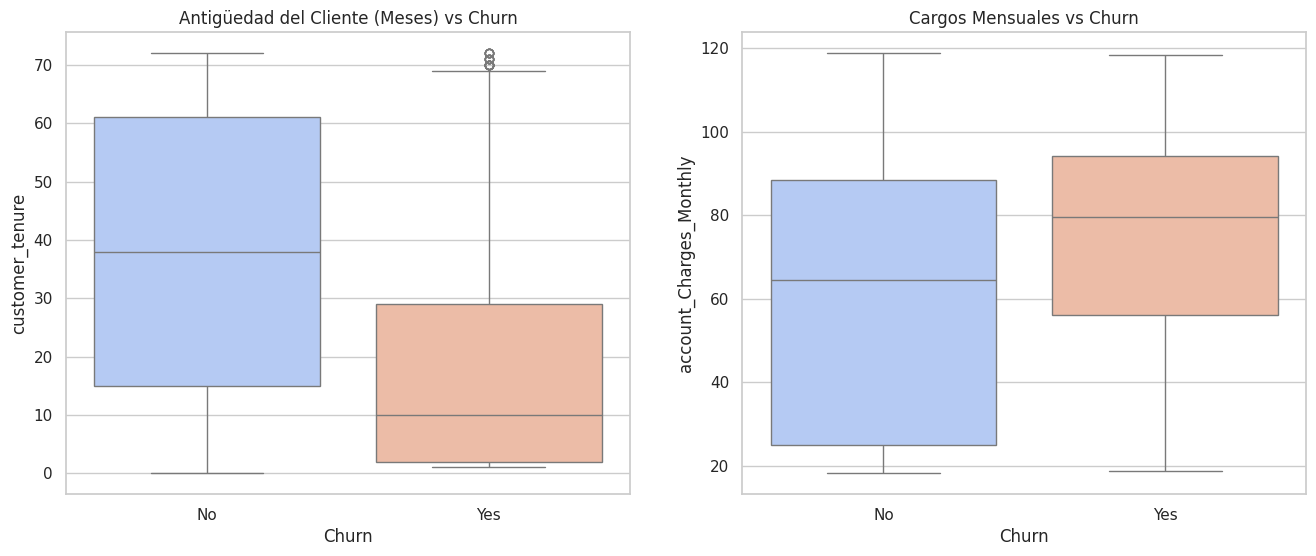

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Tenure vs Churn
sns.boxplot(x='Churn', y='customer_tenure', data=df, ax=axes[0], palette='coolwarm')
axes[0].set_title('Antigüedad del Cliente (Meses) vs Churn')

# Monthly Charges vs Churn
sns.boxplot(x='Churn', y='account_Charges_Monthly', data=df, ax=axes[1], palette='coolwarm')
axes[1].set_title('Cargos Mensuales vs Churn')

plt.show()

Tasa de abandono: 26.54%


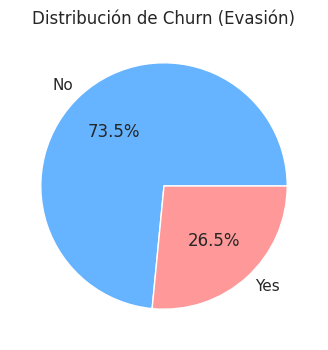

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual
sns.set_theme(style="whitegrid")

# Proporción de Churn
churn_rate = df['Churn'].value_counts(normalize=True) * 100
print(f"Tasa de abandono: {churn_rate['Yes']:.2f}%")

# Gráfico de pastel simple
plt.figure(figsize=(6, 4))
df['Churn'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['#66b3ff','#ff9999'])
plt.title('Distribución de Churn (Evasión)')
plt.ylabel('')
plt.show()

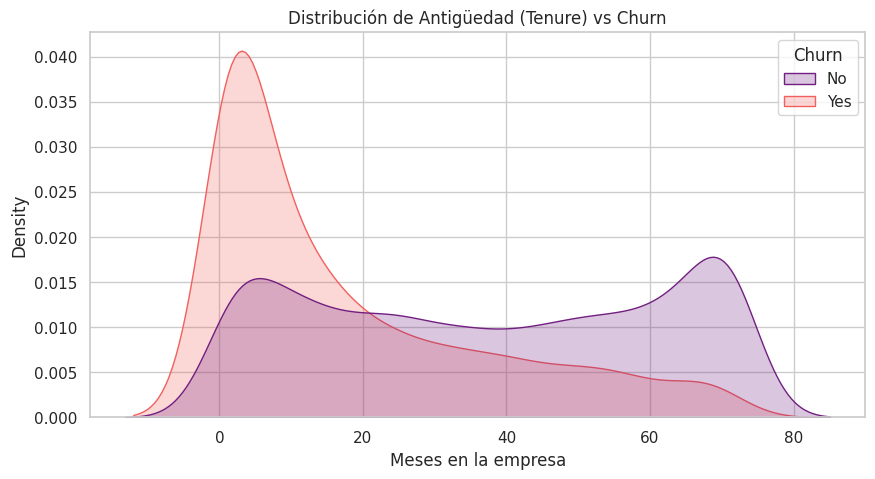

In [16]:
plt.figure(figsize=(10, 5))
sns.kdeplot(data=df, x='customer_tenure', hue='Churn', fill=True, common_norm=False, palette='magma')
plt.title('Distribución de Antigüedad (Tenure) vs Churn')
plt.xlabel('Meses en la empresa')
plt.show()

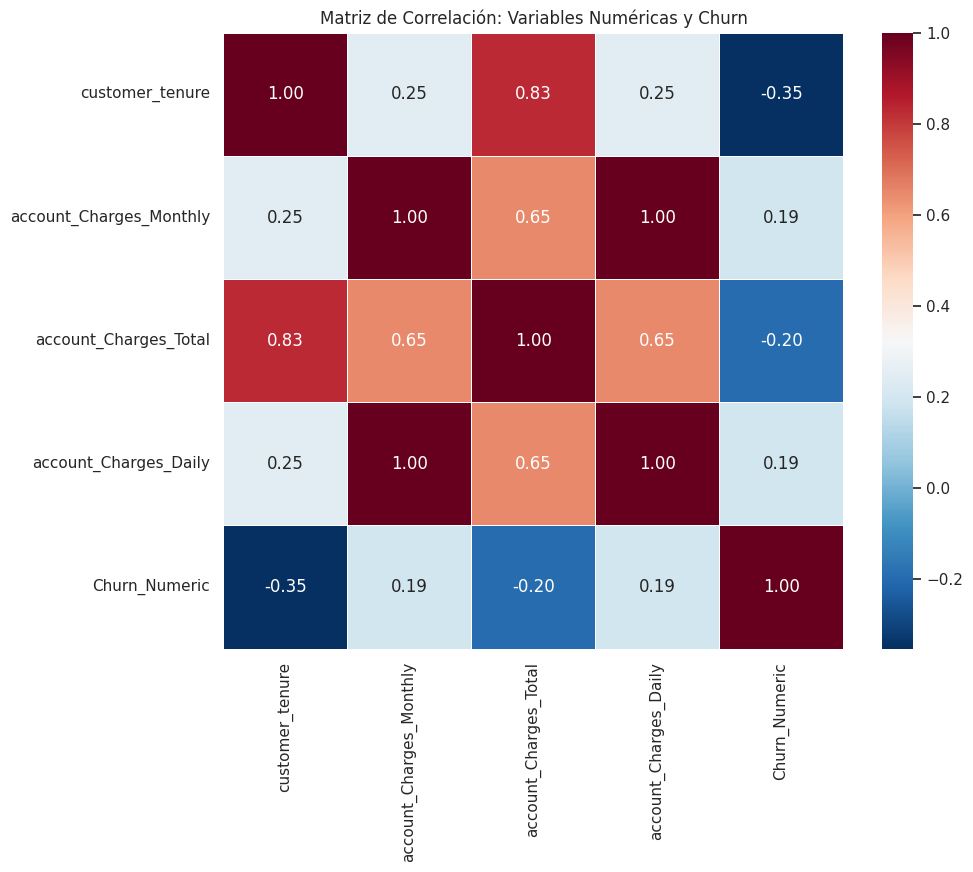

In [33]:
# 5.1 Preparación: Convertir Churn y categorías a numérico
df_corr = df.copy()
df_corr['Churn_Numeric'] = df_corr['Churn'].map({'Yes': 1, 'No': 0})

# Seleccionamos columnas numéricas incluyendo la nueva y la diaria creada anteriormente
numeric_cols = ['customer_tenure', 'account_Charges_Monthly', 'account_Charges_Total',
                'account_Charges_Daily', 'Churn_Numeric']

# 5.2 Calcular matriz de correlación
correlation_matrix = df_corr[numeric_cols].corr()

# 5.3 Visualizar con un Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='RdBu_r', fmt='.2f', linewidths=0.5)
plt.title('Matriz de Correlación: Variables Numéricas y Churn')
plt.show()

#📄Informe final

# Informe Final: Análisis de Evasión de Clientes (Churn) - Telecom X

---

## 1. Introducción
El presente análisis se enfoca en la problemática de **Telecom X**, una empresa de telecomunicaciones que enfrenta una alta tasa de abandono de clientes (**Churn**). Como analista de datos, el objetivo principal ha sido procesar la información recolectada para identificar los factores críticos que motivan a un cliente a dejar la empresa, proporcionando una base sólida de datos limpios y hallazgos estratégicos para el equipo de Ciencia de Datos.

---

## 2. Limpieza y Tratamiento de Datos
Para asegurar que el análisis fuera preciso y libre de ruido, se ejecutaron los siguientes pasos de transformación:

* **Extracción y Normalización:** Se cargaron los datos desde una API en formato JSON, aplanando las estructuras anidadas para obtener una tabla tabular clara.
* **Corrección de Formato:** Se renombraron las columnas (ej. `customer.gender` a `customer_gender`) para estandarizar el acceso a los datos en Python.
* **Tratamiento de Datos Numéricos:** La columna `account_Charges_Total` se convirtió de tipo *objeto* a *float*. Se gestionaron los valores nulos (11 registros inicialmente vacíos) asignándoles valor 0, ya que correspondían a clientes con antigüedad menor a un mes.
* **Filtrado de Inconsistencias:** Se eliminaron los registros que no presentaban información en la columna `Churn`, resultando en un dataset final de **7,043 registros**.
* **Cuentas Diarias:** Se creó la métrica `account_Charges_Daily` dividiendo la facturación mensual entre 30, permitiendo una visión del costo operativo por día.

---

## 3. Análisis Exploratorio de Datos (EDA)
Los hallazgos visuales y estadísticos revelaron patrones determinantes sobre la evasión:

### 🔹 Distribución de Evasión
* La tasa de Churn es del **26.5%**. Esto significa que más de una cuarta parte de la base de clientes está abandonando el servicio.

### 🔹 Análisis Categórico
* **Tipo de Contrato:** Los clientes con contrato **"Month-to-month"** (mes a mes) tienen la mayor probabilidad de fuga. Los contratos de 1 y 2 años actúan como fuertes retenedores.
* **Método de Pago:** Existe una fuga desproporcionada en clientes que pagan mediante **"Electronic check"**, sugiriendo una posible fricción en este proceso de pago.

### 🔹 Análisis Numérico
* **Antigüedad (Tenure):** El gráfico de densidad muestra un pico crítico de abandono entre los **0 y 6 meses**. Una vez que el cliente supera los 20 meses, su lealtad aumenta drásticamente.
* **Cargos Mensuales:** La mediana del gasto mensual de quienes se van es de aproximadamente 80 USD, mientras que los que permanecen gastan cerca de 65 USD. Los planes más costosos presentan mayor riesgo de fuga.

### 🔹 Correlación
* Se identificó una correlación negativa significativa (**-0.35**) entre la antigüedad y la evasión, confirmando que a menor tiempo en la empresa, mayor es el riesgo de pérdida del cliente.

---

## 4. Conclusiones e Insights
1.  **Zona Crítica Inicial:** La empresa está fallando en retener a los clientes nuevos. El servicio o la atención inicial no logra fidelizarlos en el primer semestre.
2.  **Sensibilidad al Precio:** Los clientes con tickets altos (planes premium) son más propensos a buscar competidores, posiblemente por una relación costo-beneficio percibida como desfavorable.
3.  **Vulnerabilidad Contractual:** La falta de contratos a largo plazo facilita la salida inmediata de los clientes ante cualquier eventualidad.

---

## 5. Recomendaciones Estratégicas
* **Optimizar el Onboarding:** Crear un programa de acompañamiento intensivo para los clientes durante sus primeros 6 meses.
* **Incentivos de Migración:** Lanzar campañas para convertir a clientes de contrato mensual a contratos anuales mediante descuentos o beneficios en el servicio.
* **Promover Pagos Automáticos:** Incentivar la transición del cheque electrónico a débito automático o tarjeta de crédito para reducir la tasa de abandono asociada a este método.
* **Fidelización Premium:** Revisar la oferta de los planes de mayor costo y añadir valores agregados (como soporte técnico prioritario) para justificar la tarifa mensual frente a la competencia.